# IEEE-30 smart grid recovery model with time-dependent transitions
Sanfan Liu, Dec 2025

In [ ]:
##!! This is not python code, run this in terminal !!##
wget https://www.mathworks.com/mpm/glnxa64/mpm && \
chmod +x mpm && \
./mpm install --release=R2025a --destination=/opt/matlab --products=MATLAB Parallel_Computing_Toolbox Deep_Learning_Toolbox Statistics_and_Machine_Learning_Toolbox && \
ln -fs /opt/matlab/bin/matlab /usr/local/bin/matlab && \
MATLAB_DEPS_URL="https://raw.githubusercontent.com/mathworks-ref-arch/container-images/main/matlab-deps/r2025a/ubuntu22.04/base-dependencies.txt" && \
MATLAB_DEPENDENCIES=base-dependencies.txt && \
wget ${MATLAB_DEPS_URL} -O ${MATLAB_DEPENDENCIES} && \
apt-get update --fix-missing && xargs -a ${MATLAB_DEPENDENCIES} -r apt-get install --no-install-recommends -y
export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/opt/matlab/bin/glnxa64 && \
python3 -m pip install jupyter-matlab-proxy matlabengine==25.1.2 && \
env MWI_APP_PORT=3000 MWI_ENABLE_AUTH_TOKEN=False matlab-proxy-app &
#https://gist.github.com/yanndebray/e267617c78a3f24c875cb57570bdd3b9/revisions

In [ ]:
from google.colab import output
output.serve_kernel_port_as_window(3000, path='?mwi-auth-token=bG-9rQ3BaKR58GRJS297wY9FkggKOXx_yPvX2v4RKos')
#Find the box begins with "Access MATLAB at:" in the terminal
#copy everything after http://localhost:3000
#and paste it to the path

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
#!!this is matlab code!!#
matlab.engine.shareEngine
matlab.engine.engineName

NameError: name 'matlab' is not defined

In [ ]:
import matlab.engine
eng = matlab.engine.connect_matlab('MATLAB_8013')

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')  #access to your Google drive
#enter your Google drive folder"simulator"
%cd drive/My\ Drive/simulator

Mounted at /content/drive/
/content/drive/My Drive/simulator


In [ ]:
eng.cd('drive')
eng.cd('My Drive')
eng.addpath('simulator')
eng.cd('simulator')
eng.addpath('psat')

'/content/drive/My Drive/simulator:/opt/matlab/toolbox/matlab/addon_enable_disable_management/matlab:/opt/matlab/toolbox/matlab/addon_updates/matlab:/opt/matlab/toolbox/matlab/addons:/opt/matlab/toolbox/matlab/addons/cef:/opt/matlab/toolbox/matlab/addons/fileexchange:/opt/matlab/toolbox/matlab/addons/supportpackages:/opt/matlab/toolbox/matlab/addons_common/matlab:/opt/matlab/toolbox/matlab/addons_desktop_registration:/opt/matlab/toolbox/matlab/addons_install_location/matlab:/opt/matlab/toolbox/matlab/addons_product:/opt/matlab/toolbox/matlab/addons_product_support/matlab:/opt/matlab/toolbox/matlab/addons_registry/matlab:/opt/matlab/toolbox/matlab/addons_sidepanel/matlab:/opt/matlab/toolbox/matlab/appcontainer:/opt/matlab/toolbox/matlab/appdesigner/app_artifact_generator:/opt/matlab/toolbox/matlab/appdesigner/appdesigner:/opt/matlab/toolbox/matlab/appdesigner/appdesigner/interface:/opt/matlab/toolbox/matlab/appdesigner/appdesigner/runtime:/opt/matlab/toolbox/matlab/appdesigner/appdesign

Import libraries

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')  #access to your Google drive
#enter your Google drive folder"simulator"
%cd drive/My\ Drive/simulator
import pandas as pd

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
[Errno 2] No such file or directory: 'drive/My Drive/simulator'
/content/drive/My Drive/simulator


# Import datasets

D matrix for IEEE-14, in order of Line 1-20, PMU 1-3, FACTS 1-3, DS

In [ ]:
# @title
D = np.array([[
0.3036396589,0.3202320474,0,6.67E-18,0.001439688365,0,0.02953474047,0,0.01410088973,0.07718962792,0,0,0,0.01082220274,0,0,0,0.008108922866,0,0,0,0,0.006684288087,0.006698400234,0,0.006569355601,0.01450225869,0,0.0386124247,0,0.001326503021,0,0,0,0,0,0,0,0,0,0.001159263942,0.08113310011,2.37E-18,2.00E-18,2.48E-18,0.008453084938,0.2509948944,2.28E-18,0.3162171367,0.2259886038,0.2328727097,0.2308736683,0.001897867512
],[0.4208877048,0.1333454806,0,0,0,0,0.007320154345,0,0,0.04948540846,0,0,0,0.005678301786,0,0,0,0.01297832461,0,0,0,0,0.01143890833,0.01158773397,0,0,0.02470953343,0,0.01220386892,0,0.002123588995,0,0,0,0,0,0,0,0,0,0.001382266511,0.05329627392,1.99E-18,1.64E-18,2.07E-18,0.01191589557,0.3538377596,1.96E-18,0.2986872128,0.2217631871,0.2391991567,0.2266335699,0.003052272198
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006088181455
],[0.8390279986,0,0,0,0.004583560726,0,0.01605176506,0,0.007337856386,0.03774130994,0,0,0,0.002430839155,0,0,0,0,0,0,0,0,0,0,0,0.0004875920178,0,0,0.001274009488,0,0,0,0,0,0,0,0,0,0,0,0.0004786329034,0.09398127608,0,0,0,0,0,0,0.2263227024,0.148967016,0.1370622541,0.1520655082,0.00803935715
],[0.00320584666,0,0,0,0.0031910212,0,0,0.08507522517,0.9354820585,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.20E-18,0,0,0.4186046512,0.004790781139,0.005211329519,2.20E-18,0.005211329519,0.006072734064
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006076848291
],[0.03411388794,0.006440513325,0,6.35E-19,0,0,0.02561695711,0,0,0.001076589599,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.03168086131,0,0,0,0,0,0,0,0,0,0,0,0.01531982565,0.004378732653,1.11E-18,0,2.17E-19,2.14E-18,0.01976129219,2.17E-19,0.01081441523,0.02414002485,0.02971410759,0.02533537494,0.00518125199
],[0,0,0,0,4.62E-18,0,0,0.04397398677,0.006522153466,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.57E-18,1.40E-18,1.16E-18,2.03E-18,1.56E-18,1.15E-18,0.2350343324,1.44E-18,1.34E-18,1.17E-18,1.54E-18,0.003051407299
],[0.004653231373,0,0,4.82E-19,1.72E-17,0,0,0.4781529635,0.1388055028,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.50E-18,1.85E-18,9.55E-19,3.02E-18,1.92E-18,2.16E-18,0.2606517122,0.0052708835,2.13E-18,1.07E-18,8.23E-19,0.002938845262
],[0.03082849735,0.01027473979,0,3.89E-18,0,0,0.01165078357,0,0,0.04276934808,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.01613244988,0,0,0,0,0,0,0,0,0,0,0,0.03599595735,0.5525140825,1.45E-18,1.75E-19,1.43E-19,0.007277008573,0.01456366218,1.57E-19,0.06644714789,0.0793871934,0.07242197844,0.06321351898,0.004415141009
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006085830097
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006101937835
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006103123327
],[0.005464603295,0.004200643439,0,8.62E-20,0,0,0,0,0,0,0,0,0,0.01566085627,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.02197512085,0,0.04277004139,0,0,0,0,0,0,0,0,0,0,0,0,1.95E-18,0,0,0.009881544437,0,0.03336826761,0.03081419985,0.03336826761,0.002554067761,0.005694508031
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00609766442
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006095195139
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006102397184
],[0.00220533333,0.002509095167,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006005677095,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4.95E-19,0,0.006170100273,0,0.006170100273,0.006170100273,4.95E-19,0.006170100273,0.005825309519
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006104414099
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006102431143
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006101951067
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006102217425
],[4.37E-06,4.98E-06,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.20E-05,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.68E-19,0,1.29E-05,1.68E-19,1.29E-05,1.29E-05,1.29E-05,1.29E-05,0.005825019239
],[0.0002752698465,0.0003141874737,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0006024242794,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.94E-19,0,0.0007305817967,0,6.94E-19,0.0007305817967,0.0007305817967,0.0007305817967,0.00582518543
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006102401646
],[0.0003212858022,0,0,3.44E-19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0004682476338,0,0,0.01771836554,0,0,0,0,0,0,0,0,0,0,0,0,1.43E-20,0,0,0,0,0,0,0.0004960106671,0.0004960106671,1.43E-20,0.0004960106671,0.005960244176
],[0.003146189647,0.003591735594,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00720610891,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.91E-19,0,6.45E-19,0,0.008593615746,0,0.008593615746,6.45E-19,0.008593615746,1.91E-19,0.005572120399
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006102426499
],[0.001290577562,0.0005058411261,0,2.28E-18,0,0,0.01123188423,0,0,6.74E-05,0,0,0,2.39E-05,0,0,0,0,0,0,0,0,0,0,0,0.0001225043193,0,0,0.01109948889,0,0,0,0,0,0,0,0,0,0,0,0.00303405414,0.0003119950465,1.06E-18,1.07E-19,3.81E-18,8.02E-20,0.001269241276,4.08E-19,0.01008323889,0.009863954089,0.009752319375,0.01007924168,0.004494801504
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006102397054
],[0.000728412899,0.0008315157423,0,0,0,0,0,0,0,0,0,0,0,0.006396365369,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.001636608596,0,0,0,0,0,0,0,0,0,0,0,0,1.02E-18,0,0,0.001958971174,0,0.004777782333,0.004777782333,0.004777782333,1.02E-18,0.005825043943
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006102512485
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006103678387
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006109993253
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006104771767
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.589255651,0,0,0,0,0,0,0,0,0,0.006112057071
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006102511985
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.589255651,0,0,0,0,0,0,0,0,0.006103131492
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006102261775
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.589255651,0,0,0,0,0,0,0,0.006103724937
],[0.002223584505,0.001992111505,0,4.98E-19,0,0,0.002776744201,0,0,0.002953496178,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0001041839039,0,0,0,0,0,0,0,0,0,0,0,0.003220549196,0.004569011999,0,0,4.44E-18,0.5660941055,4.44E-18,0,0.01671043724,0.01667675388,0.01667675388,8.16E-19,0.005693707846
],[0.04959402518,0.02558315934,0,9.55E-20,0,0,0.0001107389187,0.001803863255,0.02074743461,0.02206736754,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.06E-05,0,0,0.001574824579,0,0,0,0,0,0,0,0,0,0,0,0.003246075974,0.0874260355,0.01464422328,0.01464422328,0.01464422328,0.01993669186,0.02733019026,0.008875739645,0.0527642259,0.05223020402,0.04437606041,0.04286273464,0.0007578639491
],[0.03653654309,0.02088362634,0,0,0,0,0.002740127315,0.001893496212,0.02082072111,0.00343279108,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0004675492632,0,0.0001128699356,0,0,0,0,0,0,6.68E-19,0,0,0,0,0,0.0277942468,0.05434782609,0.01537188655,0.01537188655,0.01537188655,0.0215161591,0.009316770186,0.02438153094,0.01565668287,0.02258851768,0.01900249116,0.0007954545292
],[0.03653971308,0.02088493107,0,0,0,0,0,0.001893496212,0.02082068492,0.001755817878,0,0,0,0.001490915151,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4.57E-05,0,0.0002271313215,0,0,0,0,0,0,3.88E-18,0,0,0,0.01986633871,0.01537188655,0.05434782609,0.01537188655,0.01537188655,0.003586026517,0.009316770186,0.008156763971,0.007272176356,0.007512394583,0.00489860332,0.0007954851525
],[0.03653980391,0.02088431652,0,0,0.0005978557469,0,0.0006139094401,0.001893496212,0.02082077195,0.001480065366,0,0,0,0,0,0,0,0.0007454174883,0,0,0,0,1.64E-06,8.35E-05,0,0,0.0005908289247,0,7.53E-05,0,0,0,0,0,0,0,0,0,0,6.93E-19,0.0005428124257,0.01847747661,0.01537188655,0.01537188655,0.05434782609,0.01814961074,0.0215161591,0.009316770186,0.02070785678,0.01688161204,0.015328817,0.0172094779,0.0007957045127
],[0.03747572506,0.02208114043,0,0,0,0,0.001029648917,0.001881807964,0.02069207072,0.002714786065,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5.67E-05,0,0,0,0,0,0,0,0,0,0,0,0.00255867559,0.02096107486,0.01527699836,0.01527699836,0.01527699836,0.05895061728,3.45E-19,0.009259259259,0.01004537203,0.008024691358,0.008024691358,0.001543209877,0.001118349841
],[0.07281989189,0.06343024966,0,0,0,0,0.001462129079,0.001789742995,0.01967966651,0.008874656268,0,0,0,0.005355137914,0,0,0,0.004373670652,0,0,0,0,0.00395549899,0.003900489239,0,0,0.007771484985,0,0.01591625092,0,0.0007788578874,0,0,0,0,0,0,0,0,0,0.0005985808256,0.03253299836,0.01210799283,0.01210799283,0.01210799283,0.01517109965,0.1050228311,0.0102739726,0.09610418727,0.07327313704,0.07647387629,0.07540246448,0.0009087654877
],[0.03575702141,0.02043899181,0,0,0,0,0.0007009887933,0.07099409551,0.08205786488,0.0009437429895,0,0,0,0,0,0,0,0,0,0,0,0,1.87E-06,0,0,0,0,0,9.90E-06,0,0,0,0,0,0,0,0,0,0,0,0,0.01608345357,0.01253735428,0.01253735428,0.01253735428,0.01253735428,0.01228404828,0.09574468085,0.01228404828,0.00818936552,0.00818936552,0.00818936552,0.001620078254
],[0.09074761911,0.05456510819,0,2.65E-18,0.00237608064,0,0.006054737529,0.001724768827,0.02320660094,0.02249487155,0,0,0,0.006078480658,0,0,0,0.00421489053,0,0,0,0,0.003811900017,8.88E-05,0,0.001865767162,0.007489351866,0,0.01857870854,0,0.003501484891,0,0,0,0,0,0,0,0,0,0.003083829725,0.0477358059,0.01166842873,0.01166842873,0.01166842873,0.01694895679,0.08465873833,0.009900990099,0.1288228823,0.09632175568,0.09616520469,0.09552127428,0.0008672375578
],[0.07757723762,0.04778079175,0,9.71E-19,0.002164920477,0,0.002108543365,0.001814600537,0.01995454368,0.0221749244,0,0,0,0.00456018148,0,0,0,0.004434416078,0,0,0,0,0.004010436476,0.003954662701,0,0.001962942536,0.0006605795617,0,0.009793617377,0,0.003683853896,0,0,0,0,0,0,0,0,0,0.003478107656,0.04869878786,0.0122761594,0.0122761594,0.0122761594,0.01783171495,0.06992927633,0.01041666667,0.09943964564,0.1021412037,0.09560926674,0.09287081141,0.001569211804
],[0.07775773629,0.04978825232,0,9.68E-19,0.0006661230121,0,0.003762970381,0.001808321642,0.0198839431,0.01938165814,0,0,0,0.006372939929,0,0,0,0.0008305343641,0,0,0,0,0.003996559533,0.003940978747,0,7.09E-05,0.007852157839,0,0.01556238536,0,0.003671106996,0,0,0,0,0,0,0,0,0,0.003466072682,0.04553365225,0.01223368134,0.01223368134,0.01223368134,0.01777001352,0.07491902323,0.01038062284,0.109187836,0.09647324665,0.1032295271,0.0889968328,0.001563782005
],[0.07848675632,0.04838663749,0,1.07E-18,0.002164920477,0,0.004112849232,0.001814600537,0.01995307285,0.0184418761,0,0,0,0.003501812681,0,0,0,0.004434416078,0,0,0,0,0.004010436476,0.003954662701,0,0.001962942536,0.0005227460512,0,0.01756499984,0,0.0002539454359,0,0,0,0,0,0,0,0,0,6.98E-05,0.04154443857,0.0122761594,0.0122761594,0.0122761594,0.01473139127,0.07899156401,0.01041666667,0.1000578033,0.09024429952,0.08675130277,0.1004050926,0.000889641851
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
]])

In [ ]:
D = D**(1/4)

SCI value for each state

In [ ]:
# @title
def reward_calculation(X_t):
  tempX = np.zeros(N)
  location = 0
  if X_t.sum() > 4:
    return 0.0
  if X_t.sum() == 0:
    return 1.0
  for i in range(0, N):   #swap 1 and 0s, because MATLAB was coded differently
    if X_t[i] != 0:
      tempX[i] = 1
    else:
      tempX[i] = 0
  for i in range(0, N):   #reverse 1 and 0s
    tempX[i] = 1-tempX[i]
  eng.workspace['my_matlab_array'] = X_t
  return eng.get_SCI_30(eng.workspace['my_matlab_array'])

# Functions for simulation

NEXT state

In [ ]:
# @title
#function to find the failed components in the next state
#x_t, comopnent system state
#t, current time step
def Next_state(X_t, t, failure_counter):
  fail_propagation = np.zeros(N)
  for i in range(0, N):
    if X_t[i] != 0:
      # Calculate element-wise power for D, as (t-X_t[i]) can be a float.
      # The original line 'D_temp = matrix_power(input_array, 0)D**(t-X_t[i])' was syntactically incorrect.
      D_temp = D**(t-X_t[i]+1)
      fail_propagation = fail_propagation + D_temp[i]
  for i in range(0, N):
    RV = random.uniform(0,1)
    if fail_propagation[i] > RV:
      if X_t[i] == 0:
        failure_counter = failure_counter + 1
        X_t[i] = t
  return (X_t, failure_counter)

Check repair condition

In [ ]:
# @title
#function to schedule the crew to work on failed components
# note that component index doesnt prefect align with crew's state because crew has to have one extra state for idle
# so for N components, crews has N+1 state and the idling state will always be the (N)th state
# dictionary for all variables used:
#X_t, component-level system state, X_t[i] has 2 states, 0 & 1, 0 operational, 1 failed
#Y_t, crew state, Y_t[i] = the current repair task of crew i (the component crew i is fixing)
#z_t, amount of time left for crew to finish working on the current task
#repair_counter, count the total number of tasks assigned
def repair_condition(X_t, Y_t, z_t , repair_counter):
  z_t = z_t - 1
  for i in range(0, M):
    if z_t[i] <= 0:             #find finished repairs
      if Y_t[i]<N:
        X_t[int(Y_t[i])] = 0                     #component got repaired set to operational
      Y_t[i] = N                       #crew set to be idle
  #collect failed components
  fail_list = []
  for i in range(0, N):
    if X_t[i] != 0:               #find failed component
      fail_list.append(i)           #append the failed component into failure list
      for j in range(0, M):
        if i == Y_t[j]:         #if crew is already working on fixing this comonent
          fail_list.pop()     #remove the component from the list
  if fail_list == []:         #end repair scheduling algorithm if nothing to assign
    return (X_t, Y_t, z_t, repair_counter)

  (fail_list, Y_t, z_t, repair_counter) = assign_repair(fail_list, Y_t, z_t, repair_counter)
  return (X_t, Y_t, z_t, repair_counter)

Assign repair tasks to crews

In [ ]:
# @title
def sort_fail_list_by_pre_list(pre_list, fail_list):
  """
  Sorts fail_list according to the order of elements in pre_list.

  Args:
    pre_list: A list containing numbers from 0 to 27 in a specific order.
    fail_list: A list containing a subset of numbers from 0 to 27.

  Returns:
    A new list with elements from fail_list sorted according to pre_list.
  """
  # Convert fail_list to a set for efficient lookup
  fail_set = set(fail_list)
  sorted_fail_list = []

  for item in pre_list:
    if item in fail_set:
      sorted_fail_list.append(item)
      # Optional: if you want to remove elements from fail_set as they are found
      # This would be useful if fail_list can have duplicates that should all be included
      # fail_set.remove(item)
  return sorted_fail_list

# Example Usage:
# pre_list_example = [5, 1, 8, 3, 2, 0, 7, 6, 4, 9]
# fail_list_example = [3, 7, 1, 9]
# sorted_list = sort_fail_list_by_pre_list(pre_list_example, fail_list_example)
# print(sorted_list) # Output: [1, 3, 7, 9]

In [ ]:
# @title
#function to assign repair tasks to idling crews
#fail_list, list of all failed, not under repair, components
#y_t, crew state
#repair_counter, count the number of tasks assigned

def assign_repair(fail_list, Y_t, z_t, repair_counter):
  for i in range(0, 19):      # setup repair time for Lines
      repair_time[i] = inverse_lognormal_cdf(np.random.rand(), mu=1, sigma=0.15)     #hours
  for i in range(19, N-1):      # setup repair time for smart devices
      repair_time[i] = (inverse_exponential_cdf(np.random.rand(), 0.1)+1)/60   #hours
  #extend repair time for area under weather, line 1, 3, 4, 5, 6, pmu1, FACTS 1 and 3.
  global algorithm  #0-randomized, 1-pre-computed list, 2-look-ahead, 3-dynamic dependency
  for i in range(0, M):
    if Y_t[i] == N:   #check for idling crews
      if not fail_list:  # Check if fail_list is empty
        return (fail_list, Y_t, z_t, repair_counter) # Return immediately if empty
      repair_counter = repair_counter + 1
      match algorithm:
        case 0: #randomized method
          random.shuffle(fail_list)     # shuffle fail_list
          Y_t[i] = fail_list[0]         # assign the first component to idling crew
          z_t[i] = repair_time[fail_list[0]] #assign repair time to coresponding tracker
          fail_list.remove(fail_list[0])              #remove component from the fail list
        case 1: #pre_computed list
          global pre_list               #fetch pre-computed list
          sorted_list = sort_fail_list_by_pre_list(pre_list, fail_list)
          Y_t[i] = sorted_list[0]         # assign the first component to idling crew
          z_t[i] = repair_time[sorted_list[0]] #assign repair time to coresponding tracker
          fail_list.remove(sorted_list[0])              #remove component from the fail list
        case 2: #look ahead
          best_component = fail_list[0] #fetch first component on the list
          if len(fail_list) > 1:      #if only 1 component, then skip comparision
            X_u = np.copy(X_t)
            X_u[best_component] = 0   #assume first component is repair
            best_reward = (reward_calculation(X_t) - reward_calculation(X_u)/repair_time[best_component]) #find the performance when its repaired
            for j in range(1, len(fail_list)):    #for the rest of components on the list
              X_v =  np.copy(X_t)
              X_v[fail_list[j]] = 0   #assume jth component is fixed
              temp_reward = (reward_calculation(X_t) - reward_calculation(X_v)/repair_time[fail_list[j]]) #find its reward after its fixed
              if temp_reward > best_reward:      #compare the performance gap
                best_reward = temp_reward        #keep the better performance
                best_component = fail_list[j]     # keep the better component
          Y_t[i] = best_component   #assign the best component to repair crew
          z_t[i] = repair_time[best_component] #assign repair time
          fail_list.remove(best_component) #remove from the list
        case 3: #dynamic dependency
          best_component = fail_list[0] # fetch first component from the list
          if len(fail_list) > 1:        #if there is more than one failed component
            highest_effect=0
            for k in range(0, N):
              if X_t[k] == 0:
                highest_effect = highest_effect + D[best_component][k]
            highest_effect = highest_effect / repair_time[best_component] #find the dependency effect caused by best_component
            for j in range(1, len(fail_list)):  #compare with other components
              temp_effect = 0
              for k in range(0, N):
                if X_t[k] == 0:
                  temp_effect = temp_effect + D[fail_list[j]][k]    #find the dependency effect caused by fail_list[j]
              temp_effect = temp_effect / repair_time[fail_list[j]]  #find the dependency effect caused by testing component
              if temp_effect < highest_effect:
                highest_effect = temp_effect
                best_component = fail_list[j]
          Y_t[i] = best_component   #assign the best component to repair crew
          z_t[i] = repair_time[best_component] #assign repair time
          fail_list.remove(best_component) #remove from the list
        case _: #handle invalid algorithms
          print("invalid algorithm")
          sys.exit()

  return (fail_list, Y_t, z_t, repair_counter)

Inverse probability math functions

In [ ]:
# @title
def inverse_weibull_cdf(p, lambda_val, k_val): #written by Gemini, double checked by Sanfan
    """Inverse of the cumulative distribution function (CDF) for a Weibull distribution.
    Args:
        p (float): The probability (0 <= p < 1).
        lambda_val (float): The scale parameter (lambda) of the Weibull distribution.
        k_val (float): The shape parameter (k) of the Weibull distribution. which is the indicator of the distribution, k> 1 means success rate increase, k<1 means failure rate decrease.
    Returns:
        float: The value x such that F(x) = p.
    """
    if not (0 <= p < 1):
        raise ValueError("Probability 'p' must be between 0 and 1 (exclusive of 1).")

    # Inverse CDF formula: x = lambda * (-ln(1 - F(x)))^(1/k)
    x = lambda_val * ((-np.log(1 - p)))**(1/k_val)
    return x


In [ ]:
# @title
import numpy as np

def inverse_exponential_cdf(p, lambda_val):
    """Inverse of the cumulative distribution function (CDF) for an Exponential distribution.

    Args:
        p (float): The probability (0 <= p < 1).
        lambda_val (float): The rate parameter (lambda) of the Exponential distribution.

    Returns:
        float: The value x such that F(x) = p.
    """
    if not (0 <= p < 1):
        raise ValueError("Probability 'p' must be between 0 and 1 (exclusive of 1).")
    if lambda_val <= 0:
        raise ValueError("Lambda (rate parameter) must be greater than 0.")

    # Inverse CDF formula: x = - (1/lambda) * ln(1 - p)
    x = - (1 / lambda_val) * np.log(1 - p)
    return x

# Example usage:
# probability = 0.5
# rate_parameter = 0.1 # This means an average of 10 events per unit time
# value_at_p = inverse_exponential_cdf(probability, rate_parameter)
# print(f"For p={probability} and lambda={rate_parameter}, x = {value_at_p}")


In [ ]:
# @title
def inverse_weibull_cdf(p, lambda_val, k_val): #written by Gemini, double checked by Sanfan
    """Inverse of the cumulative distribution function (CDF) for a Weibull distribution.
    Args:
        p (float): The probability (0 <= p < 1).
        lambda_val (float): The scale parameter (lambda) of the Weibull distribution.
        k_val (float): The shape parameter (k) of the Weibull distribution. which is the indicator of the distribution, k> 1 means success rate increase, k<1 means failure rate decrease.
    Returns:
        float: The value x such that F(x) = p.
    """
    if not (0 <= p < 1):
        raise ValueError("Probability 'p' must be between 0 and 1 (exclusive of 1).")

    # Inverse CDF formula: x = lambda * (-ln(1 - F(x)))^(1/k)
    x = lambda_val * ((-np.log(1 - p)))**(1/k_val)
    return x


In [ ]:
# @title
import numpy as np
from scipy.stats import norm

def inverse_lognormal_cdf(p, mu, sigma):
    """Inverse of the cumulative distribution function (CDF) for a Lognormal distribution.

    Args:
        p (float): The probability (0 < p < 1).
        mu (float): The mean of the logarithm of the random variable.
        sigma (float): The standard deviation of the logarithm of the random variable.

    Returns:
        float: The value x such that F(x) = p.
    """
    if not (0 < p < 1):
        raise ValueError("Probability 'p' must be between 0 and 1 (exclusive).")
    if sigma <= 0:
        raise ValueError("Standard deviation 'sigma' must be greater than 0.")

    # The inverse lognormal CDF is exp(mu + sigma * Z), where Z is the
    # inverse standard normal CDF (ppf) of p.
    x = np.exp(mu + sigma * norm.ppf(p))
    return x

# Example usage:
# probability = 0.5
# mu_param = 0.0
# sigma_param = 0.5
# value_at_p = inverse_lognormal_cdf(probability, mu_param, sigma_param)
# print(f"For p={probability}, mu={mu_param}, sigma={sigma_param}, x = {value_at_p}")

In [ ]:
print (1/0) # pause run-cell and below

ZeroDivisionError: division by zero

# Inputs for simulation


In [ ]:
#position 0~40 lines, 41~45 FACTS, 46~51 PMUs, 52 DS
N = 53                      #number of components
M = 4                       #number of crews
Max_sim_time = 50          #max simulation time in hours
sim_trials = 10           #number of trials we are going to run
#choose repair algorithm
algorithm = 2               #0-randomized, 1-pre-computed, 2-Max_capacity, 3-Min_cascade
pre_list = np.array([52, 22, 5, 10, 2, 15, 14, 11, 20, 21, 38, 29, 16, 24, 27, 19, 36, 31, 12, 32, 18, 34, 33, 23, 25, 30, 17, 26, 28, 13,  6, 43, 45,  7, 44, 42, 47, 41, 37, 39, 35, 40, 46, 51, 49, 50, 48, 8, 9, 4, 3, 1, 0])
repair_time = np.zeros(N)
random.seed(0)

# Run Simulation

In [ ]:
# @title
result = np.zeros( Max_sim_time)
repair_attemp_record = np.zeros(200)
average_Performance = np.zeros(Max_sim_time)
total_repair_attemp = 0
total_additional_failure = 0
success_rate = sim_trials
deadline_counter = sim_trials
for failure in range(0, 1):
  failure_case = np.zeros(N)
  failure_case[22] = 1
  failure_case[5] = 1
  for trial in range(0, sim_trials):
    random.seed(trial)
    np.random.seed(trial)
    systemPerformance =  np.ones(Max_sim_time)
    repair_counter = 0  #count the number of tasks assigned
    failure_counter = 0 #count the number of failed components
    X_t = np.zeros(N)
    Y_t = np.zeros(M)     #crew state at current time
    for i in range(0, M):
      Y_t[i] = N
    z_t = np.zeros(M)   # repair time tracker
    t=1   #current time
    X_t = np.copy(failure_case)
    while((t < Max_sim_time-1) and (X_t.sum() != 0) ):
      #randomize repair time
      (X_t, Y_t,  z_t, repair_counter) = repair_condition(X_t, Y_t, z_t, repair_counter)
      (X_t, failure_counter) = Next_state(X_t, t, failure_counter)
      t = t + 1
      systemPerformance[t] = reward_calculation(X_t)# work on finding system performance
      if t == 12:
        if systemPerformance[t] < 0.9:
          deadline_counter = deadline_counter - 1
      if t > Max_sim_time-2:
        success_rate = success_rate - 1
    result[t] = result [t] +1
    total_repair_attemp = total_repair_attemp + repair_counter;
    total_additional_failure = total_additional_failure + failure_counter
    average_Performance = average_Performance + systemPerformance
    if trial%10 == 0:
      print(trial)

average_Performance = (average_Performance / (sim_trials) )
average_success_rate = success_rate / (sim_trials)
total_repair_attemp = (total_repair_attemp/(sim_trials) -1)
total_additional_failure = (total_additional_failure/(sim_trials))
repair_duration = 0         #find average repair time in hours
for i in range(0, Max_sim_time):
  repair_duration = repair_duration + result[i] * i
repair_duration = (repair_duration / sim_trials)
deadline_counter = deadline_counter / (sim_trials)

0


# Result organizing functions

In [ ]:
print(total_additional_failure)  #find number of additional failures

7.1


In [ ]:
print(repair_duration)

7.3


In [ ]:
print(deadline_counter)

0.9


In [ ]:
print(average_success_rate)

1.0


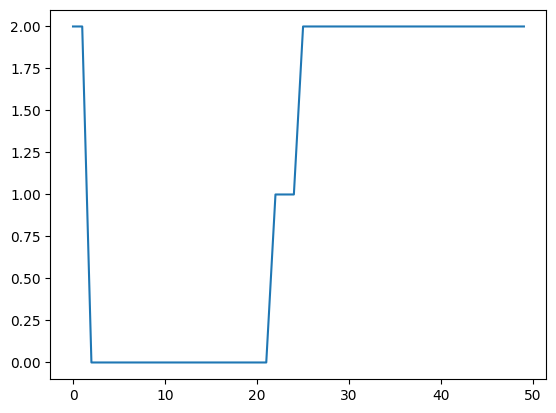

In [ ]:
plt.plot(average_Performance)
plt.show()

In [ ]:
df = pd.DataFrame(average_Performance)
df.to_csv("averagePerformance.csv")

In [ ]:
print(1/0)

ZeroDivisionError: division by zero

# unit test functions

for running a single trial in case L1 fails

In [ ]:
result = np.zeros( Max_sim_time)
repair_attemp_record = np.zeros(200)
average_Performance = np.zeros(Max_sim_time)
total_repair_attemp = 0
for failure in range(0, 2):
  failure_case = np.zeros(N)
  failure_case[failure] = 1
  print(failure)
  for trial in range(0, 1):
    random.seed(trial)
    np.random.seed(trial)
    systemPerformance =  np.ones(Max_sim_time)
    repair_counter = 0
    failure_counter = 0

    X_t = np.zeros(N)    #smart grid state at current time
    Y_t = np.zeros(M)     #crew state at current time
    for i in range(0, M):
      Y_t[i] = N
    repair_tracker = np.zeros(M)   # repair time tracker
    t=1   #current time
    begin = False
    X_t = np.copy(failure_case)    #smart grid state at current time
    while((t < Max_sim_time-1) and ( (X_t.sum()) != 0) ) :
      print(X_t,',', Y_t,',', repair_tracker,',', repair_counter,',', systemPerformance[t],',', failure_counter)
      (X_t, Y_t,  repair_tracker, repair_counter) = repair_condition(X_t, Y_t, repair_tracker, repair_counter)
      (X_t, failure_counter) = Next_state(X_t, t, failure_counter)
      t = t + 1
      systemPerformance[t] = reward_calculation(X_t)# work on finding system performance
    total_repair_attemp = total_repair_attemp + repair_counter;
    average_Performance = average_Performance + systemPerformance
if t < Max_sim_time-2:
      print("success")

0
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.] , [53. 53. 53. 53.] , [0. 0. 0. 0.] , 0 , 1.0 , 0
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0.
 1. 0. 0. 1. 1.] , [ 0. 53. 53. 53.] , [ 2.76876019 -1.         -1.         -1.        ] , 1 , 0.0 , 7
[1. 2. 0. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0. 2. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 2. 2. 1. 0.
 1. 2. 2. 1. 1.] , [ 0. 25. 40. 41.] , [1.76876019 0.03800946 0.04022179 0.22665564] , 4 , 0.0 , 15
[1. 2. 0. 0. 0. 0. 3. 3. 2. 3. 0. 0. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0. 2. 3.
 0. 0. 3. 0. 3. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 3. 0. 3. 2. 2. 1. 3.
 1. 2. 2. 1. 1.] , [ 0.  1.  8. 17.] , [0.76876019 2.79773704 2.94007625 2.71963576] , 7 , 0.0 , 24
[4. 2. 0. 0. 0. 0. 3. 3. 2. 3. 0. 0. 0. 4. 0

/tmp/ipython-input-2505655750.py:40: RuntimeWarning: invalid value encountered in scalar divide
  temp_reward = (reward_calculation(X_t) - reward_calculation(X_v)/repair_time[fail_list[j]]) #find its reward after its fixed


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1.] , [52. 53. 53. 53.] , [ 0.         -0.90031582 -0.94166262 -0.79147537] , 42 , 0.0 , 41
1
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.] , [53. 53. 53. 53.] , [0. 0. 0. 0.] , 0 , 1.0 , 0
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0.
 1. 0. 0. 1. 1.] , [ 1. 53. 53. 53.] , [ 2.96030234 -1.         -1.         -1.        ] , 1 , 0.0 , 5
[2. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0. 2. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 2. 2. 1. 0.
 1. 2. 2. 1. 1.] , [ 1. 40. 46. 48.] , [1.96030234 0.04022179 0.31095685 0.20543902] , 4 , 0.0 , 12
[2. 1. 0. 0. 0. 0. 3. 0. 0. 3. 0. 0. 0.

In [ ]:
float (inverse_weibull_cdf(0.9,3,5)) # check weibull return values

3.544576815126535

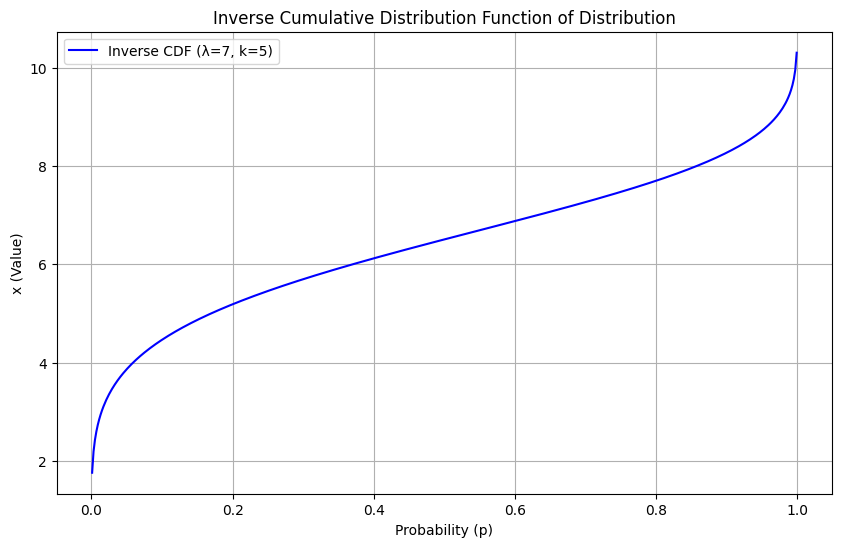

In [ ]:
#check inverse CDF function outputs, created by Gemini
import numpy as np
import matplotlib.pyplot as plt

# Define the current lambda and k values for the plot
current_lambda_val = 7
current_k_val = 5

# Generate a range of probabilities from 0 to almost 1
p_values = np.linspace(0.001, 0.999, 500) # Avoid 0 and 1 as log(0) and log(1-1) are undefined

# Calculate the corresponding x values using the inverse_weibull_cdf function
#exponential:x_values = [inverse_exponential_cdf(p, current_lambda_val) for p in p_values]
#weibull:
x_values = [inverse_weibull_cdf(p, lambda_val=current_lambda_val, k_val=current_k_val) for p in p_values]

# Plot the inverse CDF
plt.figure(figsize=(10, 6))
plt.plot(p_values, x_values, label=f'Inverse CDF (λ={current_lambda_val}, k={current_k_val})', color='blue')
plt.xlabel('Probability (p)')
plt.ylabel('x (Value)')
plt.title('Inverse Cumulative Distribution Function of Distribution')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
arr = np.zeros(len(D))
for i in range(0, len(D)):
  arr[i] =(D[i].sum())
print(arr)
ascending_indices = arr.argsort()
descending_indices = ascending_indices[::-1]
print(descending_indices)

[10.20148842  9.20954237  0.27933278  6.41116488  3.88320421  0.27920269
  4.49936839  1.67381341  2.92032871  6.13090012  0.2793058   0.27949043
  0.27950401  3.8086325   0.27944148  0.27941319  0.27949569  2.11628762
  0.27951878  0.27949608  0.27949058  0.27949363  0.72777452  1.35255694
  0.27949574  1.37143404  1.95972304  0.27949603  3.33395578  0.27949569
  2.09347044  0.27949701  0.27951036  0.27958263  0.27952288  1.15575114
  0.27949701  1.155649    0.27949414  1.1556558   3.71083921  7.18551222
  6.44374433  5.80149681  6.85235995  5.66652696  9.06699811  6.31520857
  9.85269005  9.68988641  9.66052631  9.40205606  0.        ]
[ 0 48 49 50 51  1 46 41 44 42  3 47  9 43 45  6  4 13 40 28  8 17 30 26
  7 25 23 35 39 37 22 33 34 18 32 12 31 36 19 27 24 16 29 38 21 20 11 14
 15  2 10  5 52]
